#### Carga de datos

In [19]:
#importar librerias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.types import IntegerType, DoubleType
from pyspark.sql.functions import col


df = spark.table("lh_gold.gold.fact_ventas").toPandas()
df_dim = spark.table("lh_gold.gold.dim_region").toPandas()

df = df.merge(df_dim, on="RegionID", how="left")

print(f"Filas: {df.shape[0]}  Columnas: {df.shape[1]}")
df.head()



StatementMeta(, 6ae9fa5b-7c44-4b1e-82b5-a3004db7f4fa, 23, Finished, Available, Finished, False)

Filas: 60  Columnas: 10


,VentaID,ProductoID,ClienteID,RegionID,Fecha,Cantidad,PrecioUnitario,Total,Vendedor,Region
0,1001,10,6,1,2026-04-30,1,560.0,560.0,Ana Flores,Arequipa
1,1002,8,6,5,2026-05-01,4,2400.0,9600.0,Lucia Mendoza,Piura
2,1003,1,3,6,2026-05-02,7,320.0,2240.0,None,Trujillo
3,1004,10,8,2,2026-05-04,4,560.0,2240.0,None,Chiclayo
4,1005,9,8,1,2026-05-05,7,260.0,1820.0,None,Arequipa


### Estructura y tipos

In [2]:
df.info()
df.dtypes

StatementMeta(, 6ae9fa5b-7c44-4b1e-82b5-a3004db7f4fa, 6, Finished, Available, Finished, False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   VentaID         60 non-null     int32  
 1   ProductoID      60 non-null     int32  
 2   ClienteID       60 non-null     int32  
 3   RegionID        60 non-null     int32  
 4   Fecha           60 non-null     object 
 5   Cantidad        60 non-null     int32  
 6   PrecioUnitario  60 non-null     float64
 7   Total           60 non-null     float64
 8   Vendedor        60 non-null     object 
 9   Region          60 non-null     object 
dtypes: float64(2), int32(5), object(3)
memory usage: 3.6+ KB


VentaID             int32
ProductoID          int32
ClienteID           int32
RegionID            int32
Fecha              object
Cantidad            int32
PrecioUnitario    float64
Total             float64
Vendedor           object
Region             object
dtype: object

### Vaalores Nulos

In [ ]:
%%sql
UPDATE gold.fact_ventas
SET Vendedor = null
WHERE VentaID IN (1003, 1004, 1005)

In [20]:

nulos = pd.DataFrame({
    "nulos": df.isnull().sum(),
    "pct": (df.isnull().sum() / len(df) * 100).round(2)
})
print(nulos[nulos["nulos"] > 0])

StatementMeta(, 6ae9fa5b-7c44-4b1e-82b5-a3004db7f4fa, 25, Finished, Available, Finished, False)

          nulos  pct
Vendedor      3  5.0


### Estadisticas Descriptivas

In [22]:
print(df.describe())

print(df.describe(include="object"))

StatementMeta(, 6ae9fa5b-7c44-4b1e-82b5-a3004db7f4fa, 27, Finished, Available, Finished, False)

           VentaID  ProductoID  ClienteID   RegionID  Cantidad  \
count    60.000000   60.000000  60.000000  60.000000  60.00000   
mean   1030.500000    5.150000   5.016667   3.516667   4.35000   
std      17.464249    3.052229   2.639284   1.610260   2.19263   
min    1001.000000    1.000000   1.000000   1.000000   1.00000   
25%    1015.750000    2.000000   3.000000   2.000000   3.00000   
50%    1030.500000    5.000000   5.000000   4.000000   4.00000   
75%    1045.250000    8.000000   7.250000   5.000000   6.00000   
max    1060.000000   10.000000  10.000000   6.000000   8.00000   

       PrecioUnitario         Total  
count       60.000000     60.000000  
mean      1020.583333   4611.166667  
std       1017.138347   5790.086894  
min         45.000000     45.000000  
25%        260.000000    942.500000  
50%        670.000000   2080.000000  
75%       1462.500000   5460.000000  
max       3200.000000  25600.000000  
             Fecha       Vendedor Region
count           60    

### Distrubucion (histogramas)

StatementMeta(, 6ae9fa5b-7c44-4b1e-82b5-a3004db7f4fa, 29, Finished, Available, Finished, False)

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


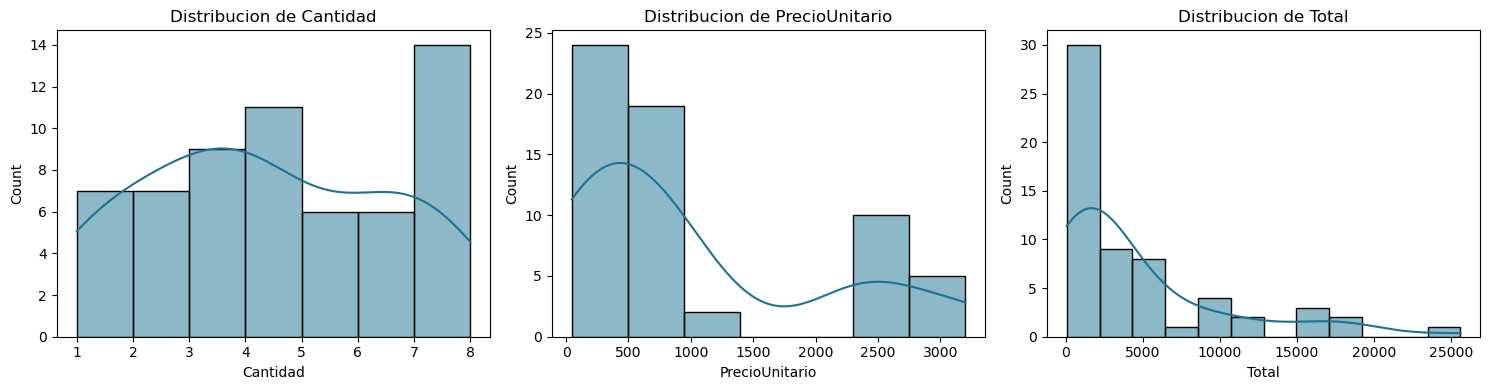

In [23]:
num_cols = ["Cantidad", "PrecioUnitario", "Total"]

fig, axes = plt.subplots(1, len(num_cols), figsize=(15, 4))
for ax, c in zip(axes, num_cols):
    sns.histplot(df[c], kde=True, ax=ax, color="#1C7293")
    ax.set_title(f"Distribucion de {c}")
plt.tight_layout()
plt.show()

### Outliers (metodo IQR)

StatementMeta(, 6ae9fa5b-7c44-4b1e-82b5-a3004db7f4fa, 32, Finished, Available, Finished, False)

Cantidad: 0 outliers (0.0%)
PrecioUnitario: 0 outliers (0.0%)
Total: 7 outliers (11.7%)


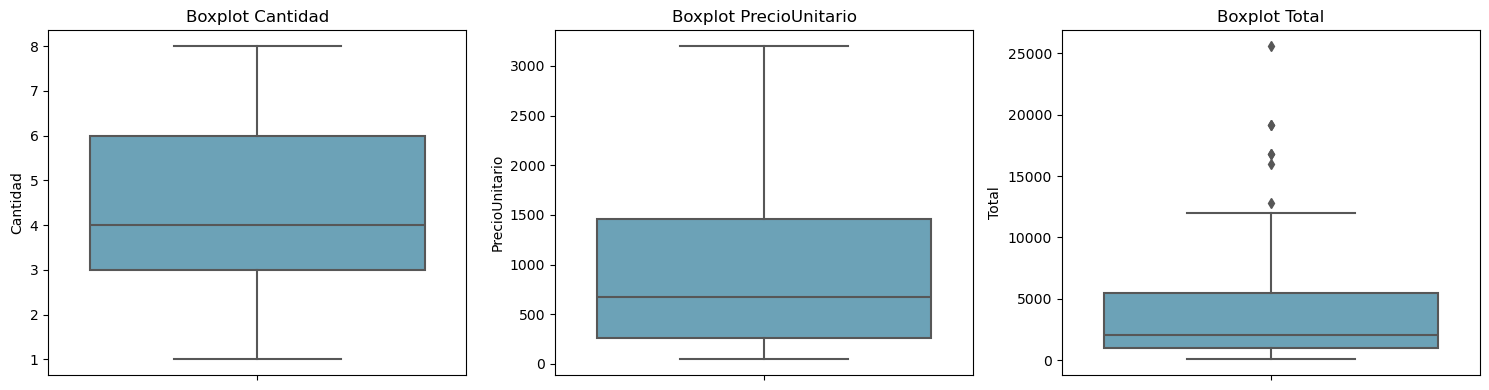

In [24]:
def outliers_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return serie[(serie < lim_inf) | (serie > lim_sup)]

for c in num_cols:
    out = outliers_iqr(df[c])
    print(f"{c}: {len(out)} outliers ({len(out)/len(df)*100:.1f}%)")

fig, axes = plt.subplots(1, len(num_cols), figsize=(15, 4))
for ax, c in zip(axes, num_cols):
    sns.boxplot(y=df[c], ax=ax, color="#5FA8C4")
    ax.set_title(f"Boxplot {c}")
plt.tight_layout()
plt.show()

### Categoricas

StatementMeta(, 6ae9fa5b-7c44-4b1e-82b5-a3004db7f4fa, 35, Finished, Available, Finished, False)

Region
Piura       13
Chiclayo    11
Lima        11
Cusco       10
Arequipa     8
Trujillo     7
Name: count, dtype: int64
Vendedor
Lucia Mendoza    17
Ana Flores       16
Maria Torres     10
Carlos Vega       7
Jose Ramirez      7
Name: count, dtype: int64


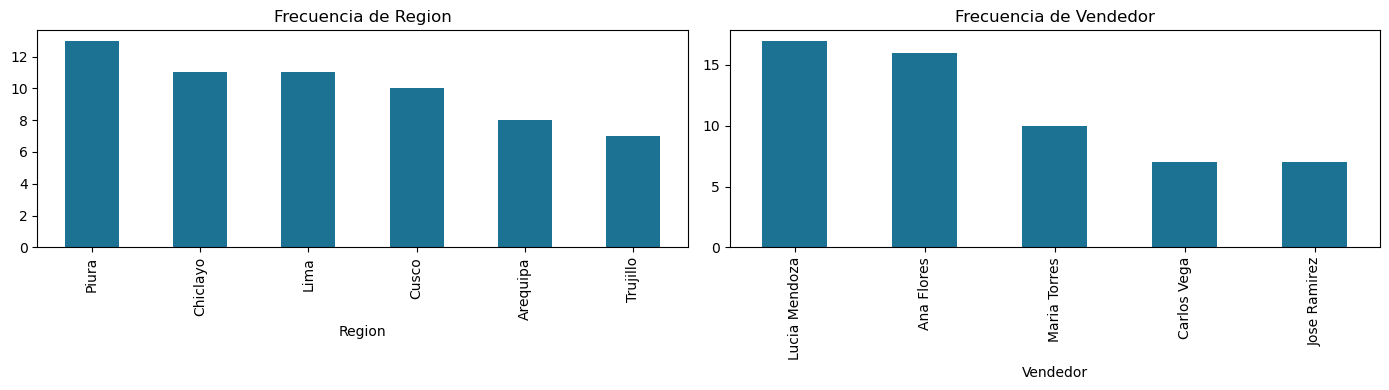

In [25]:
cat_cols = ["Region", "Vendedor"]
for c in cat_cols:
    print(df[c].value_counts())

fig, axes = plt.subplots(1, len(cat_cols), figsize=(14, 4))
for ax, c in zip(axes, cat_cols):
    df[c].value_counts().plot(kind="bar", ax=ax, color="#1C7293")
    ax.set_title(f"Frecuencia de {c}")
plt.tight_layout()
plt.show()

### Correlacion


StatementMeta(, 6ae9fa5b-7c44-4b1e-82b5-a3004db7f4fa, 38, Finished, Available, Finished, False)

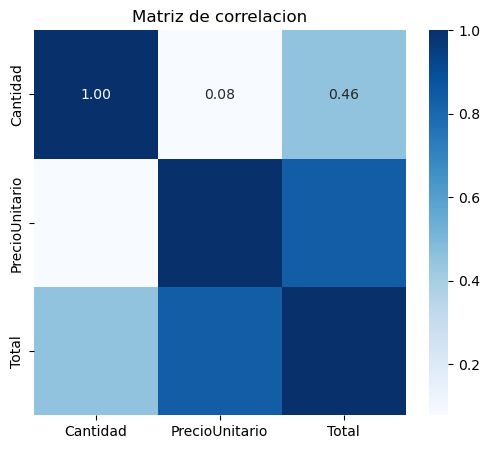

In [26]:
corr = df[num_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Matriz de correlacion")
plt.show()

### Resumen EDA

In [27]:
resumen = {
    "filas": len(df),
    "nulos_totales": int(df.isnull().sum().sum()),
    "outliers_total": len(outliers_iqr(df["Total"])),
    "region_mayor_venta": df.groupby("Region")["Total"].sum().idxmax(),
}
for k, v in resumen.items():
    print(f"{k}: {v}")

StatementMeta(, 6ae9fa5b-7c44-4b1e-82b5-a3004db7f4fa, 40, Finished, Available, Finished, False)

filas: 60
nulos_totales: 3
outliers_total: 7
region_mayor_venta: Cusco


## Iniciamos a construir el Modelo

In [28]:
# Cargar datos y castear tipos

df_spark = spark.table("gold.fact_ventas").join(
    spark.table("gold.dim_region"), "RegionID")

df_spark = (df_spark
    .withColumn("Cantidad", col("Cantidad").cast(IntegerType()))
    .withColumn("PrecioUnitario", col("PrecioUnitario").cast(DoubleType()))
    .withColumn("Total", col("Total").cast(DoubleType())))

df_spark.printSchema()

StatementMeta(, 6ae9fa5b-7c44-4b1e-82b5-a3004db7f4fa, 41, Finished, Available, Finished, False)

root
 |-- RegionID: integer (nullable = true)
 |-- VentaID: integer (nullable = true)
 |-- ProductoID: integer (nullable = true)
 |-- ClienteID: integer (nullable = true)
 |-- Fecha: date (nullable = true)
 |-- Cantidad: integer (nullable = true)
 |-- PrecioUnitario: double (nullable = true)
 |-- Total: double (nullable = true)
 |-- Vendedor: string (nullable = true)
 |-- Region: string (nullable = true)



### Feature engineering + entrenar

In [29]:
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml import Pipeline

region_idx = StringIndexer(inputCol="Region", outputCol="RegionIdx")

assembler = VectorAssembler(
    inputCols=["Cantidad", "PrecioUnitario", "RegionIdx"],
    outputCol="features")

rf = RandomForestRegressor(featuresCol="features", labelCol="Total", numTrees=20)

train, test = df_spark.randomSplit([0.8, 0.2], seed=42)

pipeline = Pipeline(stages=[region_idx, assembler, rf])

model = pipeline.fit(train)

print(model.stages)

StatementMeta(, 6ae9fa5b-7c44-4b1e-82b5-a3004db7f4fa, 42, Finished, Available, Finished, False)

[StringIndexerModel: uid=StringIndexer_757e387d7e40, handleInvalid=error, VectorAssembler_96d6a5a955a7, RandomForestRegressionModel: uid=RandomForestRegressor_871254ceff99, numTrees=20, numFeatures=3]


### Prediccion del modelo

In [30]:
from pyspark.sql import Row

venta_nueva = spark.createDataFrame([
    Row(Cantidad=5, PrecioUnitario=780.0, Region="Lima")
])

model.transform(venta_nueva).select("prediction").show()


StatementMeta(, 6ae9fa5b-7c44-4b1e-82b5-a3004db7f4fa, 43, Finished, Available, Finished, False)

+-----------------+
|       prediction|
+-----------------+
|5657.758333333333|
+-----------------+



In [31]:

# comparar contra un caso real de test
ejemplo = test.limit(1)
ejemplo.select("Cantidad", "PrecioUnitario", "Region", "Total").show()
model.transform(ejemplo).select("Total", "prediction").show()

StatementMeta(, 6ae9fa5b-7c44-4b1e-82b5-a3004db7f4fa, 44, Finished, Available, Finished, False)

+--------+--------------+--------+-----+
|Cantidad|PrecioUnitario|  Region|Total|
+--------+--------------+--------+-----+
|       1|         780.0|Arequipa|780.0|
+--------+--------------+--------+-----+

+-----+------------------+
|Total|        prediction|
+-----+------------------+
|780.0|1967.8666666666668|
+-----+------------------+



### Evaluar +  MLFLOW

In [ ]:
import mlflow
from pyspark.ml.evaluation import RegressionEvaluator

predictions = model.transform(test)

evaluator = RegressionEvaluator(labelCol="Total", predictionCol="prediction")

rmse = evaluator.setMetricName("rmse").evaluate(predictions)

r2 = evaluator.setMetricName("r2").evaluate(predictions)

print(f"RMSE={rmse:.2f}  R2={r2:.3f}")

with mlflow.start_run(run_name="rf_total_ventas"):
    mlflow.log_param("numTrees", 20)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)
    mlflow.spark.log_model(model, "modelo_ventas")

### Visulizar prediccion vs real

StatementMeta(, 6ae9fa5b-7c44-4b1e-82b5-a3004db7f4fa, 47, Finished, Available, Finished, False)

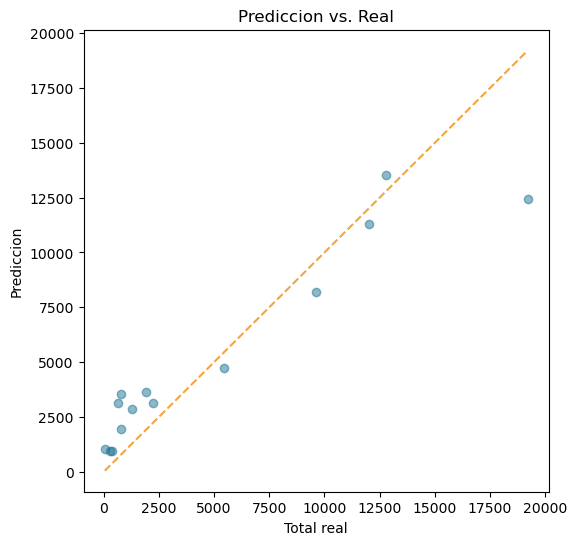

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


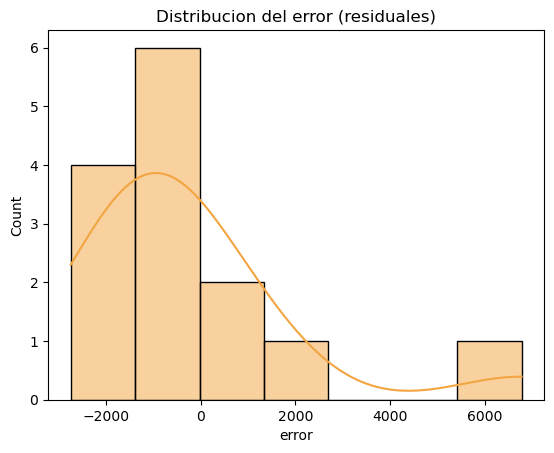

In [33]:
pred_pd = predictions.select("Total", "prediction").toPandas()

plt.figure(figsize=(6, 6))
plt.scatter(pred_pd["Total"], pred_pd["prediction"], alpha=0.5, color="#1C7293")
lims = [pred_pd[["Total","prediction"]].min().min(), pred_pd[["Total","prediction"]].max().max()]
plt.plot(lims, lims, color="#F2A541", linestyle="--")
plt.xlabel("Total real"); plt.ylabel("Prediccion")
plt.title("Prediccion vs. Real")
plt.show()

pred_pd["error"] = pred_pd["Total"] - pred_pd["prediction"]
sns.histplot(pred_pd["error"], kde=True, color="#F2A541")
plt.title("Distribucion del error (residuales)")
plt.show()